In [1]:
import torch
import os
import numpy as np
import random
import itertools
import time
import gc
import matplotlib.pyplot as plt
from IPython import display
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def init_environment():
    set_seed(42)
    torch.set_default_dtype(torch.float64)
    return get_device()

device = init_environment()

In [2]:
def get_adjacency_matrix(n,l,device):
    adj=torch.zeros(n,n,device=device)
    for i in range(n):
        row,col=i//l,i%l
        neighbors=[((row-1)%l)*l+col,((row+1)%l)*l+col,row*l+((col-1)%l),row*l+((col+1)%l)]
        for nb in neighbors:
            adj[i,nb]=1.0
    return adj

def generate_ising_data(l,beta,device):
    n=l*l
    adj=get_adjacency_matrix(n,l,device)
    states=torch.tensor(list(itertools.product([-1.,1.],repeat=n)),dtype=torch.float64,device=device)
    j_raw=torch.randn(n,n,device=device)
    j_true=0.5*(j_raw+j_raw.T)
    j_true=j_true*adj
    j_true.fill_diagonal_(0.0)
    e_true=-0.5*torch.sum((states@j_true)*states,dim=1)
    log_probs=-beta*e_true
    p_true=torch.exp(log_probs-torch.logsumexp(log_probs,dim=0))
    corr2_true=states.T@(states*p_true.unsqueeze(1))
    h_mean_true=torch.sum(e_true*p_true)
    return {'n':n,'l':l,'beta':beta,'adj':adj,'states':states,'j_true':j_true,'p_true':p_true,'corr2_true':corr2_true,'h_mean_true':h_mean_true}

In [3]:
class UniversalIsingPINN(nn.Module):
    def __init__(self,n,adj,hidden_dims,activation_fn,device):
        super().__init__()
        self.n=n
        self.adj=adj
        self.register_buffer('diag_mask',1.0-torch.eye(n,device=device))
        layers=[]
        input_dim=n
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim,h_dim))
            layers.append(activation_fn())
            input_dim=h_dim
        layers.append(nn.Linear(input_dim,n*n))
        self.mlp=nn.Sequential(*layers)

    def forward(self,x):
        out=self.mlp(x)
        matrices=out.view(-1,self.n,self.n)
        j_pred=0.5*(matrices+matrices.transpose(1,2))
        j_pred=j_pred*self.adj
        j_pred=j_pred*self.diag_mask
        return j_pred

In [4]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def compute_pinn_loss(states,j_pred_batch,corr2_true,h_mean_true,beta):
    e_pred=-0.5*torch.einsum('si,bij,sj->bs',states,j_pred_batch,states)
    log_probs=-beta*e_pred
    p_pred=torch.exp(log_probs-torch.logsumexp(log_probs,dim=1,keepdim=True))
    h_mean_pred=torch.sum(e_pred*p_pred,dim=1)
    corr2_pred=torch.einsum('si,bs,sj->bij',states,p_pred,states)
    loss_corr=torch.sum((corr2_pred-corr2_true)**2,dim=(1,2))
    loss_h=(h_mean_pred-h_mean_true)**2
    return torch.mean(loss_corr+loss_h)

def draw_progress(history, j_true, j_pred_single, epoch, current_lr):
    display.clear_output(wait=True)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(history, color='black')
    axs[0].set_yscale('log')
    axs[0].set_title(f'MSE (Epoch {epoch}, lr={current_lr:.5f})')
    axs[0].grid(True, alpha=0.3)
    
    im1 = axs[1].imshow(j_true.cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
    axs[1].set_title('J_true')
    fig.colorbar(im1, ax=axs[1])
    
    im2 = axs[2].imshow(j_pred_single.detach().cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
    axs[2].set_title('J_pred')
    fig.colorbar(im2, ax=axs[2])
    
    plt.tight_layout()
    
    display.display(plt.gcf())
    plt.close(fig)

def train_model(model,data,epochs,batch_size,lr,device,desc_text="Training"):
    clear_memory()
    optimizer=optim.Adam(model.parameters(),lr=lr)
    scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=400,gamma=0.5)
    history=[]
    states=data['states']
    p_true=data['p_true']
    corr2_true=data['corr2_true']
    h_mean_true=data['h_mean_true']
    beta=data['beta']
    j_true=data['j_true']
    single_state_eval=states[0].unsqueeze(0)
    pbar=tqdm(range(1,epochs+1),desc=desc_text)
    for epoch in pbar:
        optimizer.zero_grad()
        indices=torch.multinomial(p_true,batch_size,replacement=True)
        batch_states=states[indices]
        j_pred_batch=model(batch_states)
        loss=compute_pinn_loss(states,j_pred_batch,corr2_true,h_mean_true,beta)
        loss.backward()
        optimizer.step()
        scheduler.step()
        history.append(loss.item())
        pbar.set_postfix({'loss':f'{loss.item():.4e}'})
        if epoch%100==0 or epoch==epochs:
            display.display(pbar.container)
            j_pred_single=model(single_state_eval)[0]
            current_lr=optimizer.param_groups[0]['lr']
            draw_progress(history,j_true,j_pred_single,epoch,current_lr)
    clear_memory()
    with torch.no_grad():
        j_pred_final = model(single_state_eval)[0]
        mse_err_single = torch.mean((j_true - j_pred_final.detach())**2).item()
        mae_err_single = torch.mean(torch.abs(j_true - j_pred_final.detach())).item()
        
        j_pred_full = compute_full_grid_j_pred(model, states, batch_size=1024)
        mse_err_full = torch.mean((j_true - j_pred_full)**2).item()
        
        print(f"[{desc_text}] MSE (Single state): {mse_err_single:.4e} | MSE (Full grid): {mse_err_full:.4e}")
        
    return history, j_pred_final.detach(), mse_err_single, mae_err_single

In [5]:
def compute_full_grid_j_pred(model, states, batch_size=1024):
    model.eval()
    total_states = states.size(0)
    j_accum = torch.zeros(model.n, model.n, device=states.device)
    with torch.no_grad():
        for i in range(0, total_states, batch_size):
            batch = states[i:i+batch_size]
            j_pred_batch = model(batch)
            j_accum += j_pred_batch.sum(dim=0)
    return j_accum / total_states

# 3 на 3

In [6]:
l_3=3
beta_3=1.0
data_3x3=generate_ising_data(l_3,beta_3,device)

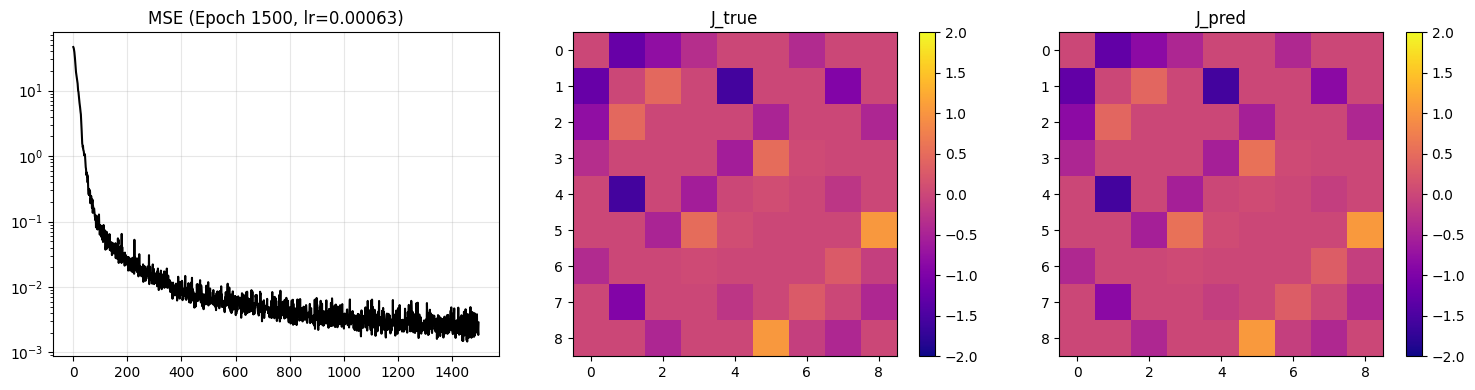

[Act:GELU] MSE (Single state): 1.2357e-03 | MSE (Full grid): 5.8799e-04


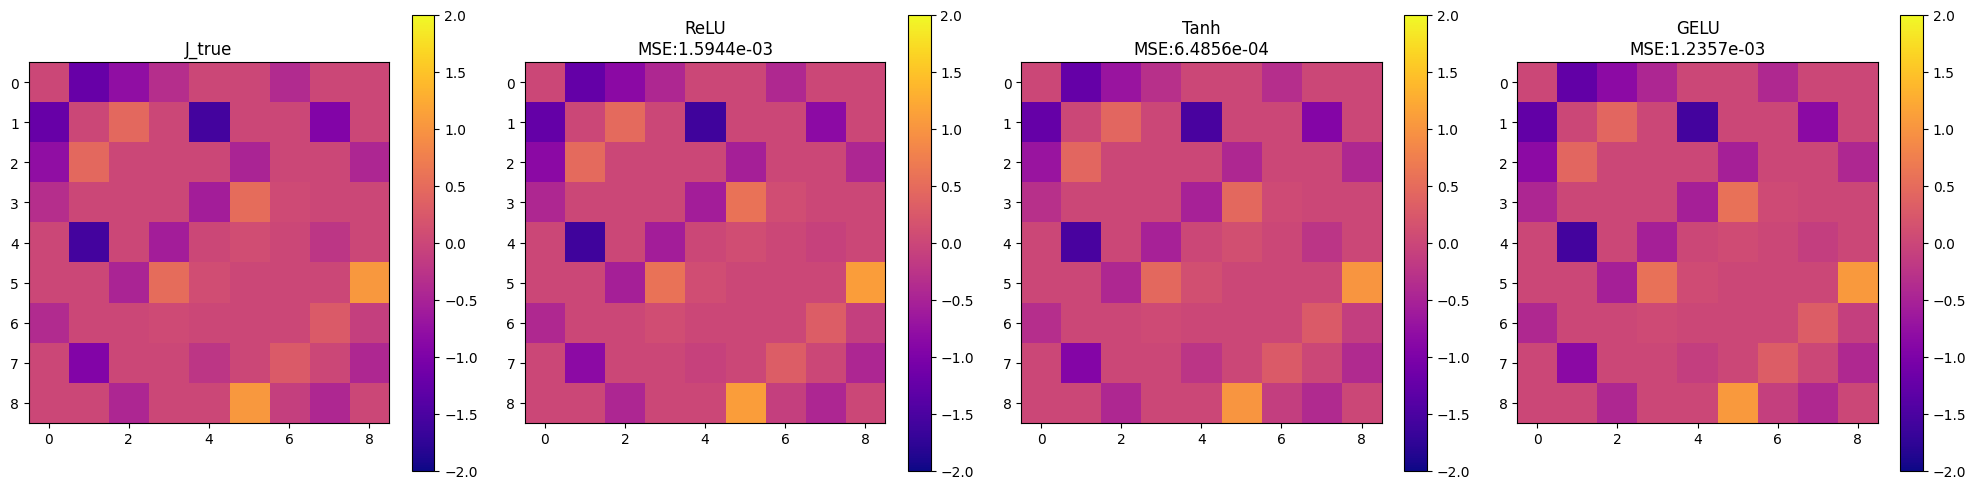

In [7]:
def run_activation_experiment(data, device):
    activations = {'ReLU': nn.ReLU, 'Tanh': nn.Tanh, 'GELU': nn.GELU}
    results = {}
    for name, act_fn in activations.items():
        set_seed(123)
        model = UniversalIsingPINN(data['n'], data['adj'], [32, 32], act_fn, device).to(device)
        hist, j_fin, mse, mae = train_model(model, data, 1500, 64, 0.005, device, f"Act:{name}")
        results[name] = {'loss': hist, 'mse': mse, 'j_final': j_fin}
    return results

def plot_activation_results(results, j_true):
    os.makedirs('plots', exist_ok=True)
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    
    im_true = axs[0].imshow(j_true.cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
    axs[0].set_title('J_true')
    fig.colorbar(im_true, ax=axs[0])
    
    for idx, (name, res) in enumerate(results.items()):
        ax = axs[idx + 1]
        im = ax.imshow(res['j_final'].cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
        ax.set_title(f'{name}\nMSE:{res["mse"]:.4e}')
        fig.colorbar(im, ax=ax)
        
    plt.tight_layout()
    
    plt.savefig('plots/experiment_1_activations.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('plots/experiment_1_activations.png', dpi=300, bbox_inches='tight')
    
    plt.show()

res_act = run_activation_experiment(data_3x3, device)
plot_activation_results(res_act, data_3x3['j_true'])

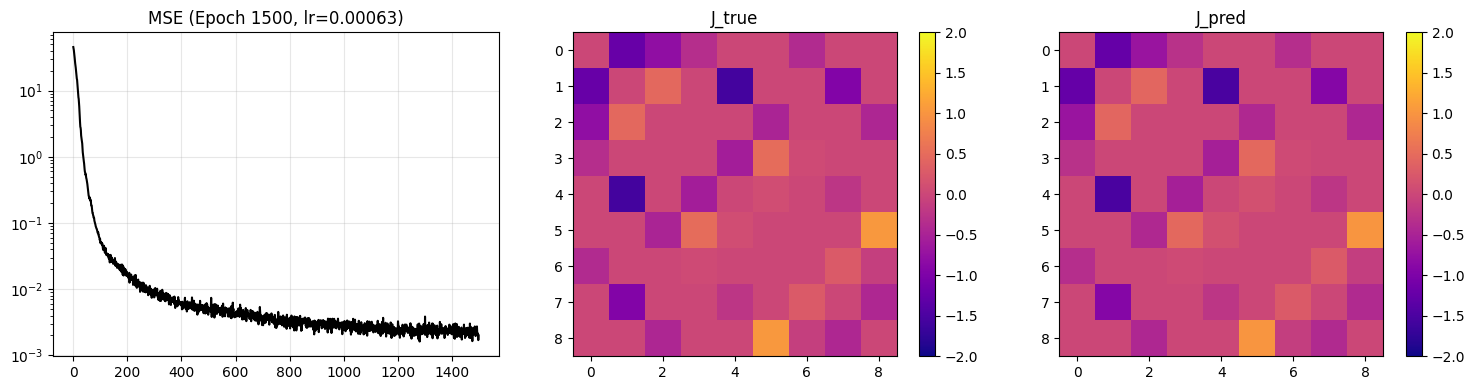

[Batch:512] MSE (Single state): 7.8863e-04 | MSE (Full grid): 3.9454e-05


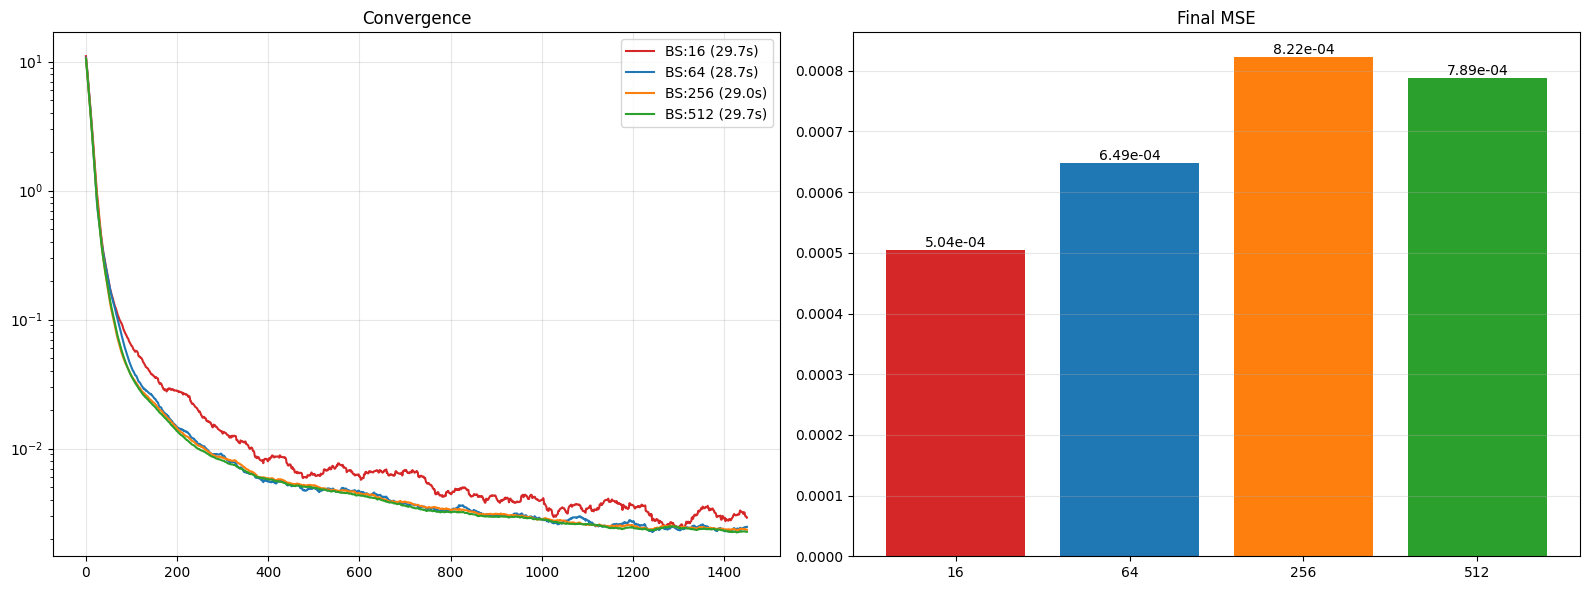

In [8]:
def run_batch_experiment(data, batch_sizes, device):
    results = {}
    for bs in batch_sizes:
        set_seed(123)
        model = UniversalIsingPINN(data['n'], data['adj'], [32, 32], nn.Tanh, device).to(device)
        start_t = time.time()
        
        hist, j_fin, mse, mae = train_model(model, data, 1500, bs, 0.005, device, f"Batch:{bs}")
        end_t = time.time()
        
        results[bs] = {'loss': hist, 'mse': mse, 'time': end_t - start_t}
    return results

def plot_batch_results(batch_sizes, results):
    os.makedirs('plots', exist_ok=True)
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    colors = {16: '#d62728', 64: '#1f77b4', 256: '#ff7f0e', 512: '#2ca02c'}
    
    for bs, res in results.items():
        smoothed = torch.tensor(res['loss']).unfold(0, 50, 1).mean(1)
        axs[0].plot(smoothed, label=f"BS:{bs} ({res['time']:.1f}s)", color=colors[bs])
        
    axs[0].set_yscale('log')
    axs[0].set_title('Convergence')
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()
    
    mses = [results[bs]['mse'] for bs in batch_sizes]
    bars = axs[1].bar([str(bs) for bs in batch_sizes], mses, color=[colors[bs] for bs in batch_sizes])
    axs[1].set_title('Final MSE')
    axs[1].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        yval = bar.get_height()
        axs[1].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2e}', ha='center', va='bottom')
        
    plt.tight_layout()
    
    plt.savefig('plots/experiment_2_batch_size.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('plots/experiment_2_batch_size.png', dpi=300, bbox_inches='tight')
    
    plt.show()

batch_sizes = [16, 64, 256, 512]
res_batch = run_batch_experiment(data_3x3, batch_sizes, device)
plot_batch_results(batch_sizes, res_batch)

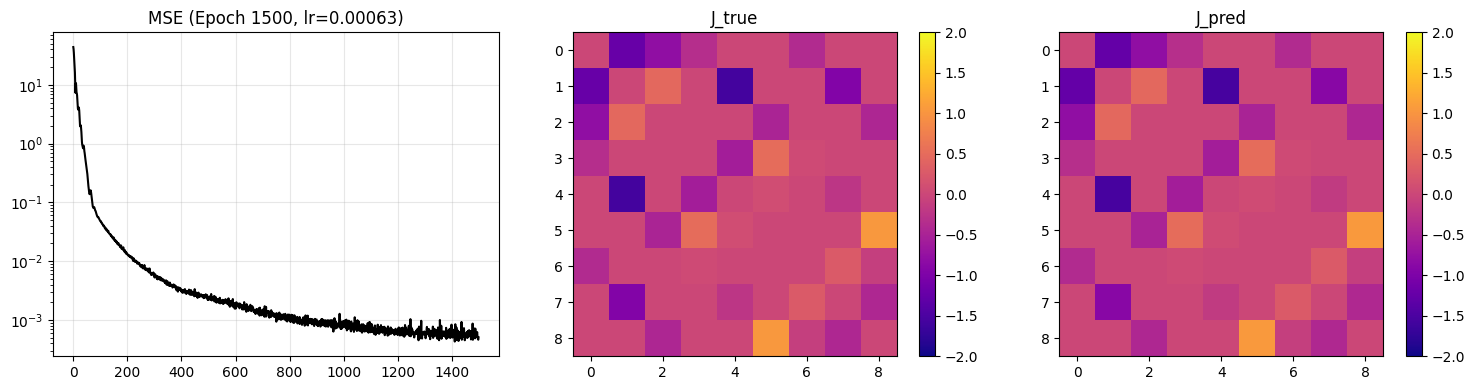

[Arch:Deep] MSE (Single state): 2.3453e-04 | MSE (Full grid): 1.2158e-04


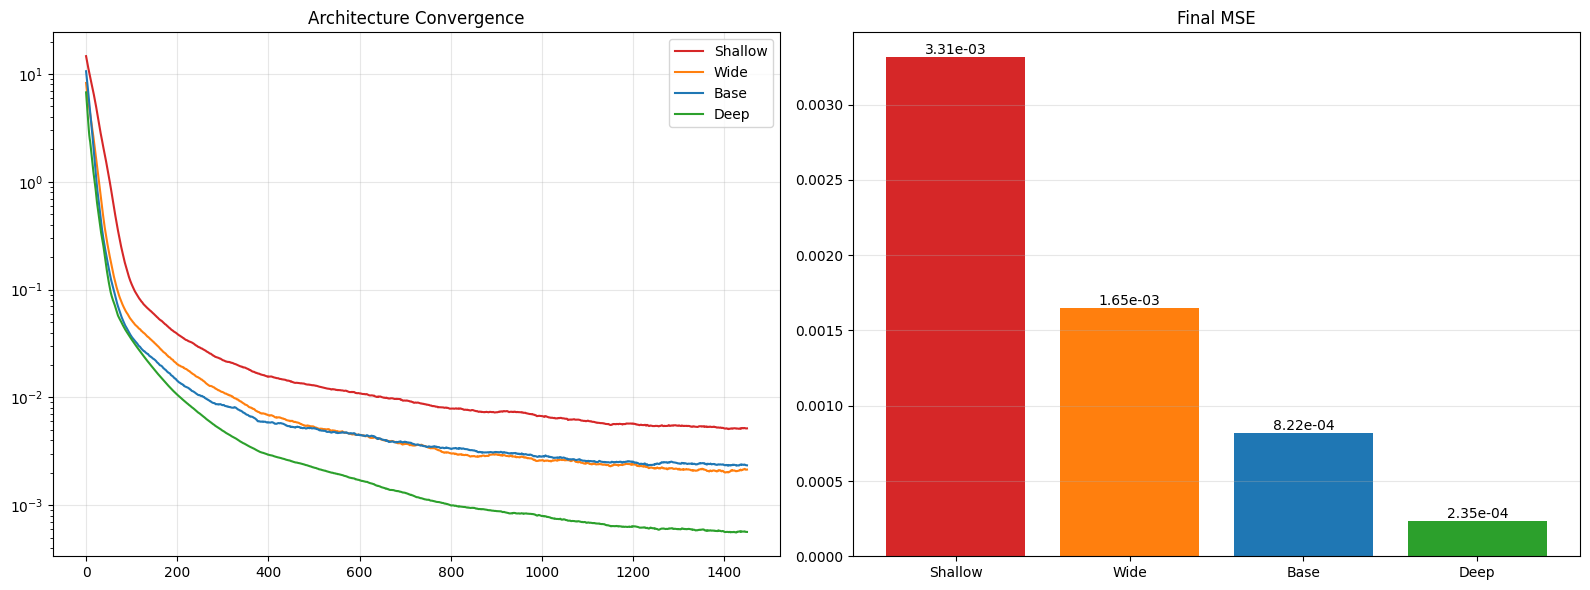

In [9]:
def run_architecture_experiment(data, architectures, device, epochs=1500, batch_size=256):
    results = {}
    for name, dims in architectures.items():
        set_seed(123)
        model = UniversalIsingPINN(data['n'], data['adj'], dims, nn.Tanh, device).to(device)
        hist, j_fin, mse, mae = train_model(model, data, epochs, batch_size, 0.005, device, f"Arch:{name}")
        results[name] = {'loss': hist, 'mse': mse}
    return results

def plot_architecture_results(results, save_name="experiment_architecture"):
    os.makedirs('plots', exist_ok=True)
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {"Shallow": '#d62728', "Wide": '#ff7f0e', "Base": '#1f77b4', "Deep": '#2ca02c'}
    
    for name, res in results.items():
        smoothed = torch.tensor(res['loss']).unfold(0, 50, 1).mean(1)
        axs[0].plot(smoothed, label=name, color=colors.get(name, '#000000'))
        
    axs[0].set_yscale('log')
    axs[0].set_title('Architecture Convergence')
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()
    
    names = list(results.keys())
    mses = [results[n]['mse'] for n in names]
    bars = axs[1].bar(names, mses, color=[colors.get(n, '#000000') for n in names])
    
    axs[1].set_title('Final MSE')
    axs[1].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        yval = bar.get_height()
        axs[1].text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2e}', ha='center', va='bottom')
        
    plt.tight_layout()

    plt.savefig(f'plots/{save_name}.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(f'plots/{save_name}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

archs = {"Shallow": [32], "Wide": [128], "Base": [32, 32], "Deep": [32, 32, 32, 32]}
res_arch = run_architecture_experiment(data_3x3, archs, device)
plot_architecture_results(res_arch)

# 4 на 4

In [10]:
l_4=4
beta_4=1.0
data_4x4=generate_ising_data(l_4,beta_4,device)

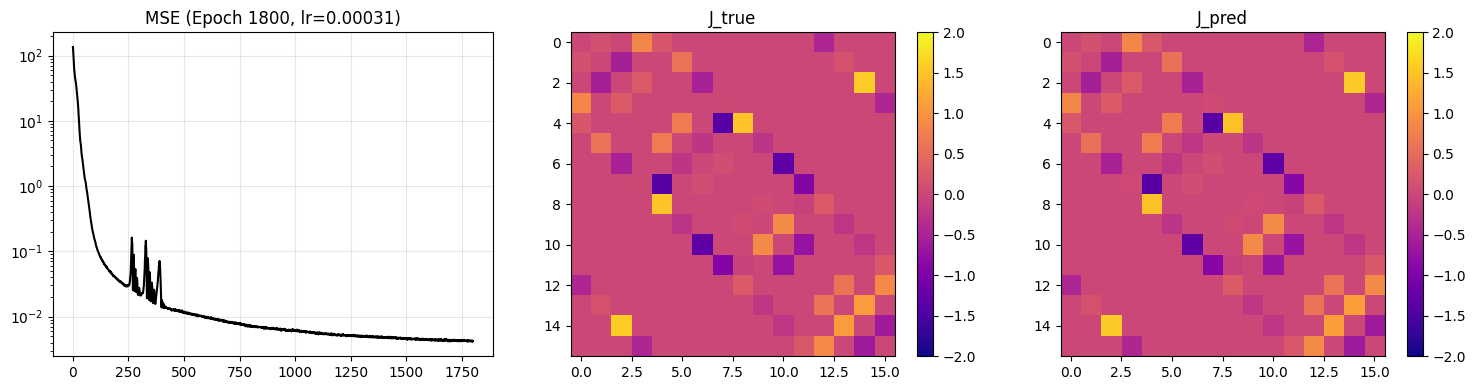

[Batch:8192] MSE (Single state): 4.1442e-05 | MSE (Full grid): 1.2905e-05


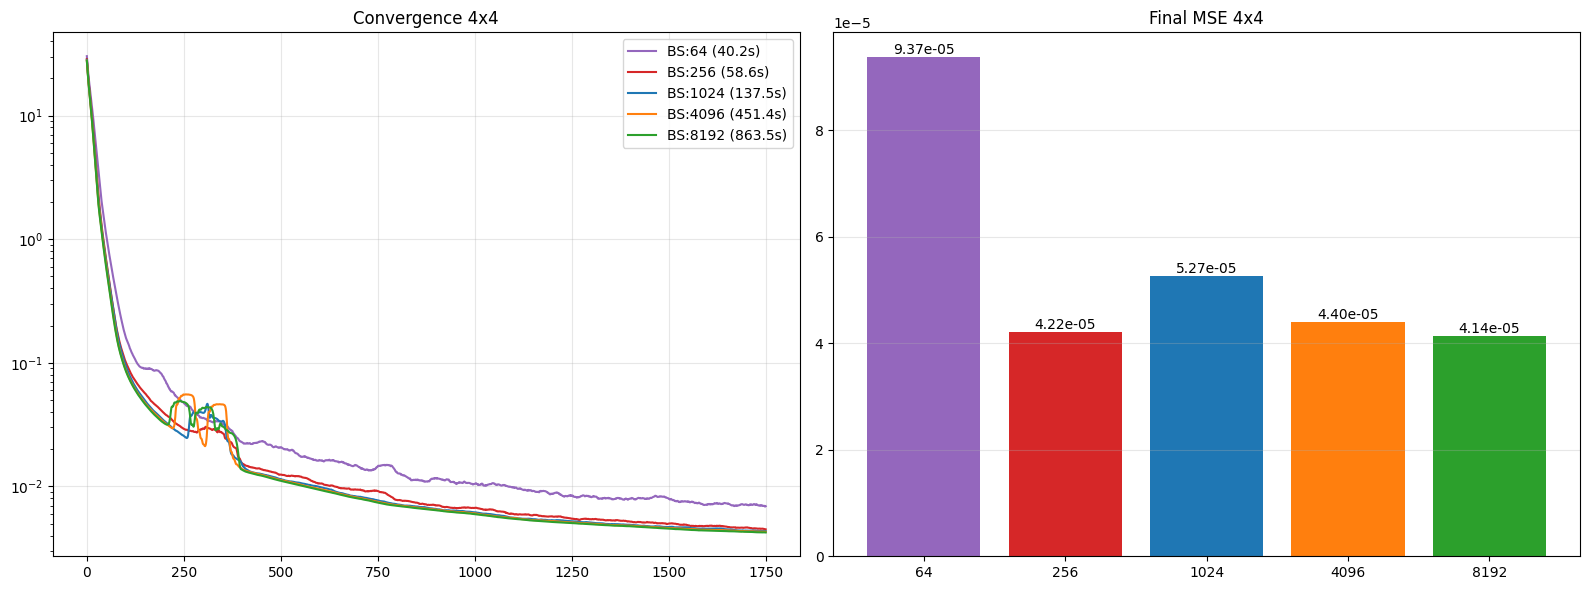

In [11]:
def run_batch_experiment_4x4(data,batch_sizes,device):
    results={}
    for bs in batch_sizes:
        set_seed(123)
        model=UniversalIsingPINN(data['n'],data['adj'],[64,64],nn.Tanh,device).to(device)
        start_t=time.time()
        hist,j_fin,mse,mae=train_model(model,data,1800,bs,0.005,device,f"Batch:{bs}")
        end_t=time.time()
        results[bs]={'loss':hist,'mse':mse,'time':end_t-start_t}
    return results

def plot_batch_results_4x4(batch_sizes,results):
    fig,axs=plt.subplots(1,2,figsize=(16,6))
    colors={64:'#9467bd',256:'#d62728',1024:'#1f77b4',4096:'#ff7f0e',8192:'#2ca02c'}
    for bs,res in results.items():
        smoothed=torch.tensor(res['loss']).unfold(0,50,1).mean(1)
        axs[0].plot(smoothed,label=f"BS:{bs} ({res['time']:.1f}s)",color=colors[bs])
    axs[0].set_yscale('log')
    axs[0].set_title('Convergence 4x4')
    axs[0].grid(True,alpha=0.3)
    axs[0].legend()
    mses=[results[bs]['mse'] for bs in batch_sizes]
    bars=axs[1].bar([str(bs) for bs in batch_sizes],mses,color=[colors[bs] for bs in batch_sizes])
    axs[1].set_title('Final MSE 4x4')
    axs[1].grid(axis='y',alpha=0.3)
    for bar in bars:
        yval=bar.get_height()
        axs[1].text(bar.get_x()+bar.get_width()/2,yval,f'{yval:.2e}',ha='center',va='bottom')
    plt.tight_layout()
    
    plt.savefig('plots/experiment_batch_size_4_4.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('plots/experiment_batch_size_4_4.png', dpi=300, bbox_inches='tight')
    
    plt.show()

batch_sizes_4x4=[64,256,1024,4096,8192]
res_batch_4x4=run_batch_experiment_4x4(data_4x4,batch_sizes_4x4,device)
plot_batch_results_4x4(batch_sizes_4x4,res_batch_4x4)

Opt:Adam:   0%|          | 0/800 [00:00<?, ?it/s]

Opt:SGD:   0%|          | 0/800 [00:00<?, ?it/s]

Opt:RMSprop:   0%|          | 0/800 [00:00<?, ?it/s]

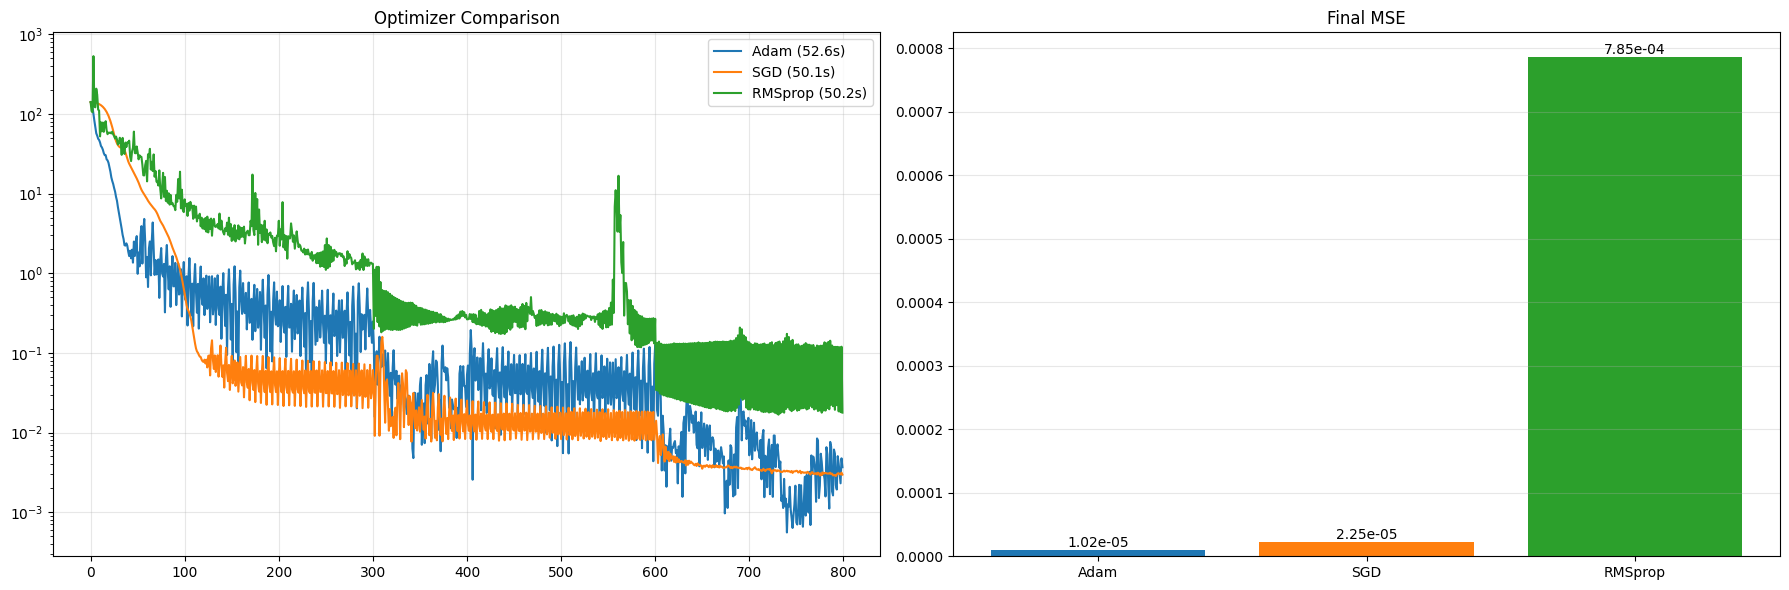

In [12]:
def train_with_optimizer(model,data,opt_func,epochs,batch_size,device,desc_text):
    clear_memory()
    optimizer=opt_func(model)
    scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=300,gamma=0.5)
    history=[]
    states=data['states']
    p_true=data['p_true']
    corr2_true=data['corr2_true']
    h_mean_true=data['h_mean_true']
    beta=data['beta']
    pbar=tqdm(range(1,epochs+1),desc=desc_text)
    for epoch in pbar:
        optimizer.zero_grad()
        indices=torch.multinomial(p_true,batch_size,replacement=True)
        batch_states=states[indices]
        j_pred_batch=model(batch_states)
        loss=compute_pinn_loss(states,j_pred_batch,corr2_true,h_mean_true,beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        optimizer.step()
        scheduler.step()
        history.append(loss.item())
        pbar.set_postfix({'loss':f'{loss.item():.4e}'})
    clear_memory()
    with torch.no_grad():
        j_pred_final=model(states[0].unsqueeze(0))[0]
        mse_err=torch.mean((data['j_true']-j_pred_final.detach())**2).item()
    return history,mse_err

def run_optimizer_experiment(data,configs,device):
    results={}
    for name,opt_func in configs:
        set_seed(123)
        model=UniversalIsingPINN(data['n'],data['adj'],[64,64,64,64],nn.Tanh,device).to(device)
        start_t=time.time()
        hist,mse=train_with_optimizer(model,data,opt_func,800,1024,device,f"Opt:{name}")
        end_t=time.time()
        results[name]={'loss':hist,'mse':mse,'time':end_t-start_t}
    return results

def plot_optimizer_results(results):
    fig,axs=plt.subplots(1,2,figsize=(18,6))
    colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728']
    for idx,(name,res) in enumerate(results.items()):
        axs[0].plot(res['loss'],label=f"{name} ({res['time']:.1f}s)",color=colors[idx])
    axs[0].set_yscale('log')
    axs[0].set_title('Optimizer Comparison')
    axs[0].grid(True,alpha=0.3)
    axs[0].legend()
    names=list(results.keys())
    mses=[results[n]['mse'] for n in names]
    bars=axs[1].bar(names,mses,color=colors[:len(names)])
    axs[1].set_title('Final MSE')
    axs[1].grid(axis='y',alpha=0.3)
    for bar in bars:
        yval=bar.get_height()
        axs[1].text(bar.get_x()+bar.get_width()/2,yval,f'{yval:.2e}',ha='center',va='bottom')
    plt.tight_layout()
    
    plt.savefig('plots/experiment_optimizer_4_4.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('plots/experiment_optimizer_4_4.png', dpi=300, bbox_inches='tight')
    
    plt.show()

opt_configs=[('Adam',lambda m:optim.Adam(m.parameters(),lr=0.005)),('SGD',lambda m:optim.SGD(m.parameters(),lr=0.01,momentum=0.9)),('RMSprop',lambda m:optim.RMSprop(m.parameters(),lr=0.005))]
res_opt=run_optimizer_experiment(data_4x4,opt_configs,device)
plot_optimizer_results(res_opt)

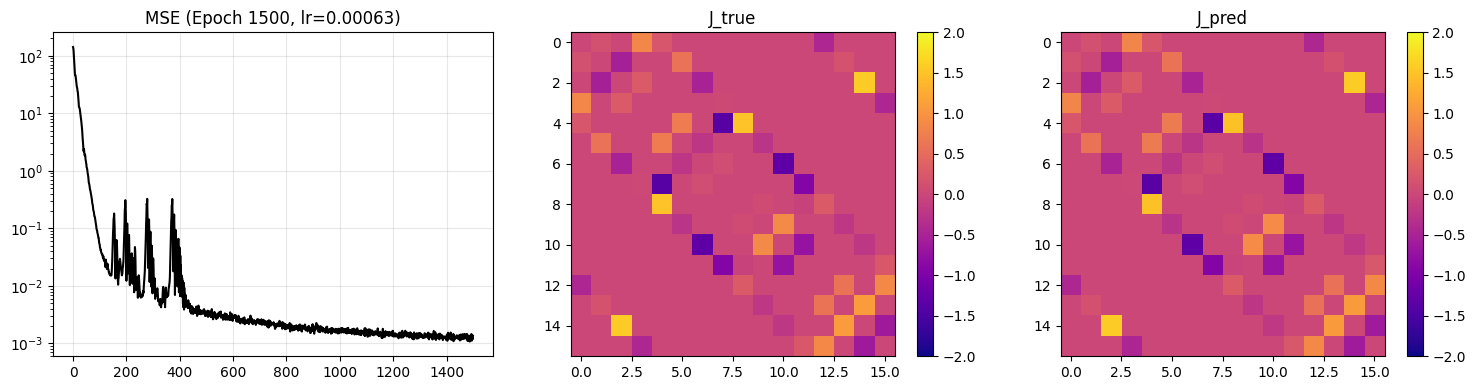

[Arch:Deep] MSE (Single state): 4.8757e-05 | MSE (Full grid): 4.4579e-06


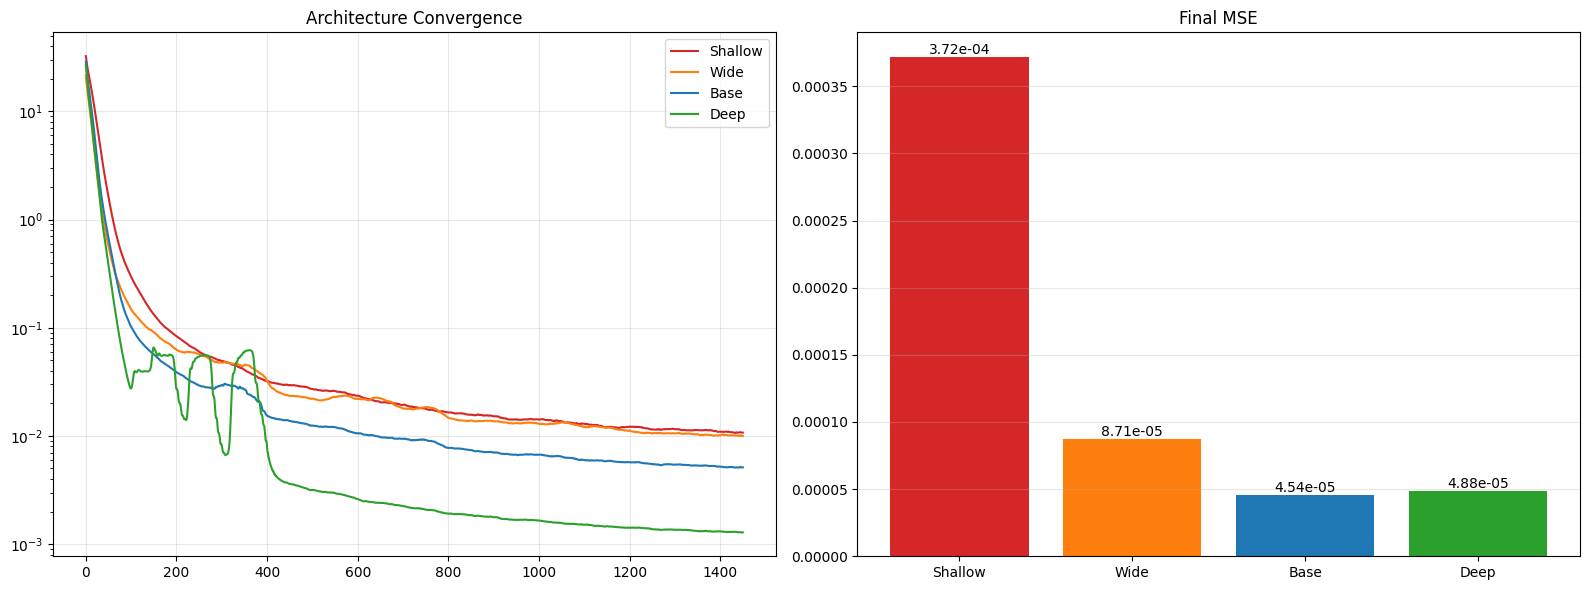

In [13]:
archs_4x4={"Shallow":[64],"Wide":[256],"Base":[64,64],"Deep":[64,64,64,64]}
res_arch_4x4=run_architecture_experiment(data_4x4,archs_4x4,device)
plot_architecture_results(res_arch_4x4)

In [14]:
def calculate_final_metrics(j_true, j_pred):
    mse = torch.mean((j_true - j_pred)**2).item()
    mae = torch.mean(torch.abs(j_true - j_pred)).item()
    max_err = torch.max(torch.abs(j_true - j_pred)).item()
    
    print(f"Final MSE: {mse:.4e}")
    print(f"Final MAE: {mae:.4e}")
    print(f"Final Max Error: {max_err:.4e}")

def run_adam_phase(model,data,epochs,batch_size):
    optimizer=optim.Adam(model.parameters(),lr=0.005)
    scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=500,gamma=0.5)
    history=[]
    pbar=tqdm(range(1,epochs+1),desc="AdamPhase")
    for epoch in pbar:
        optimizer.zero_grad()
        indices=torch.multinomial(data['p_true'],batch_size,replacement=True)
        batch_states=data['states'][indices]
        j_pred_batch=model(batch_states)
        loss=compute_pinn_loss(data['states'],j_pred_batch,data['corr2_true'],data['h_mean_true'],data['beta'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        optimizer.step()
        scheduler.step()
        history.append(loss.item())
        pbar.set_postfix({'loss':f'{loss.item():.4e}'})
    return history

def run_lbfgs_phase(model,data,max_iter,batch_size):
    optimizer=optim.LBFGS(model.parameters(),lr=0.01,max_iter=max_iter,line_search_fn="strong_wolfe")
    history=[]
    indices=torch.multinomial(data['p_true'],batch_size,replacement=True)
    lbfgs_states=data['states'][indices]
    def closure():
        optimizer.zero_grad()
        j_pred_batch=model(lbfgs_states)
        loss=compute_pinn_loss(data['states'],j_pred_batch,data['corr2_true'],data['h_mean_true'],data['beta'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        history.append(loss.item())
        return loss
    optimizer.step(closure)
    return history

def run_hybrid_training(data,device):
    clear_memory()
    set_seed(123)
    model=UniversalIsingPINN(data['n'],data['adj'],[128,128,128,128,128],nn.Tanh,device).to(device)
    hist_adam=run_adam_phase(model,data,2000,1024)
    hist_lbfgs=run_lbfgs_phase(model,data,1000,1024)
    full_history=hist_adam+hist_lbfgs
    with torch.no_grad():
        j_pred_final=model(data['states'][0].unsqueeze(0))[0]
        mse_err=torch.mean((data['j_true']-j_pred_final.detach())**2).item()
    return model,full_history,mse_err,j_pred_final.detach()

def plot_hybrid_results(history,mse,j_pred,j_true,adam_epochs):
    fig,axs=plt.subplots(1,3,figsize=(18,5))
    hist_tensor=torch.tensor(history)
    smoothed=hist_tensor.unfold(0,50,1).mean(1)
    axs[0].plot(smoothed,color='black')
    axs[0].axvline(x=adam_epochs,color='red',linestyle='--')
    axs[0].set_yscale('log')
    axs[0].set_title(f'Adam+L-BFGS(MSE:{mse:.4e})')
    axs[0].grid(True,alpha=0.3)
    im1=axs[1].imshow(j_true.cpu().numpy(),cmap='plasma',vmin=-2,vmax=2)
    axs[1].set_title('J_true')
    fig.colorbar(im1,ax=axs[1])
    im2=axs[2].imshow(j_pred.cpu().numpy(),cmap='plasma',vmin=-2,vmax=2)
    axs[2].set_title('J_pred')
    fig.colorbar(im2,ax=axs[2])
    plt.tight_layout()
    
    plt.savefig('plots/experiment_adam_lbfgs.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('plots/experiment_adam_lbfgs.png', dpi=300, bbox_inches='tight')
    
    plt.show()


AdamPhase:   0%|          | 0/2000 [00:00<?, ?it/s]

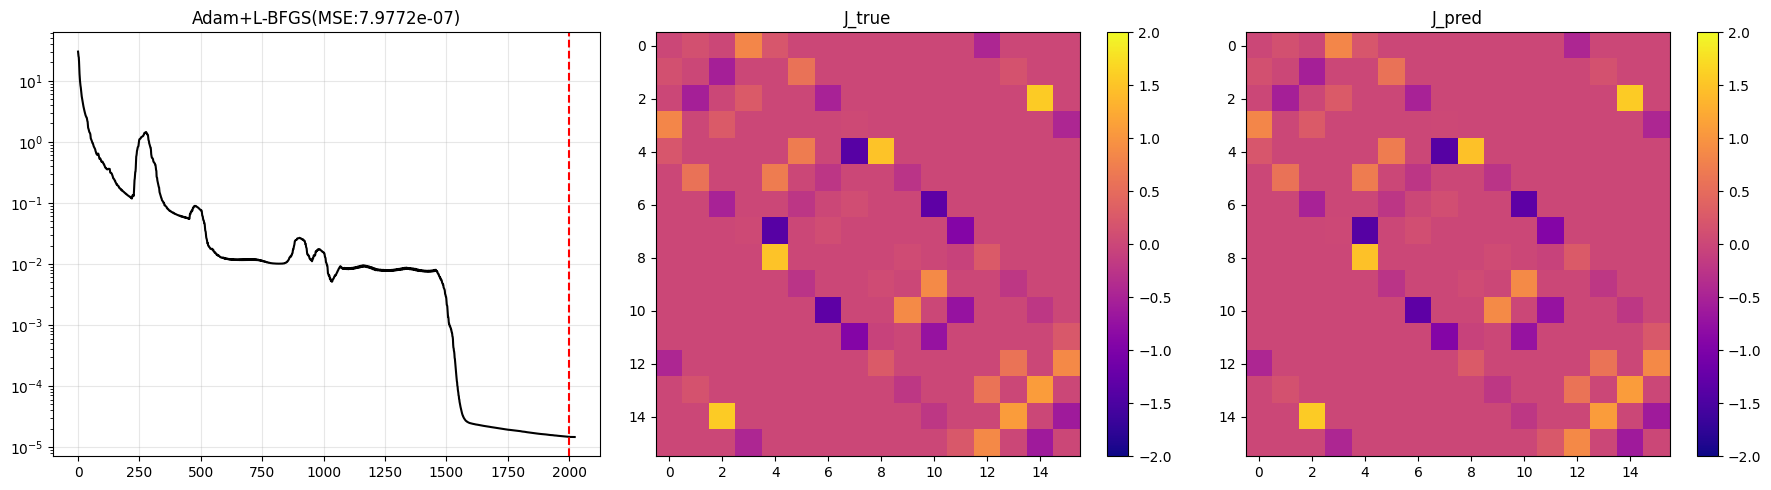

Final MSE: 7.9772e-07
Final MAE: 3.5183e-04
Final Max Error: 5.3844e-03
Full Grid MSE: 1.8686e-08
Full Grid MAE: 5.0886e-05
Full Grid Max Error: 7.3480e-04


In [15]:
model_hyb,hist_hyb,mse_hyb,j_pred_hyb=run_hybrid_training(data_4x4,device)
plot_hybrid_results(hist_hyb,mse_hyb,j_pred_hyb,data_4x4['j_true'],2000)
calculate_final_metrics(data_4x4['j_true'],j_pred_hyb)

j_pred_full=compute_full_grid_j_pred(model_hyb,data_4x4['states'],batch_size=1024)

mse_full=torch.mean((data_4x4['j_true']-j_pred_full)**2).item()
mae_full=torch.mean(torch.abs(data_4x4['j_true']-j_pred_full)).item()
max_err_full=torch.max(torch.abs(data_4x4['j_true']-j_pred_full)).item()

print(f"Full Grid MSE: {mse_full:.4e}")
print(f"Full Grid MAE: {mae_full:.4e}")
print(f"Full Grid Max Error: {max_err_full:.4e}")

## пришло время экзотики

### 1) добавим свёртку

In [16]:
def plot_hybrid_results(history, mse, j_pred, j_true, adam_epochs, save_name="experiment_hybrid"):
    os.makedirs('plots', exist_ok=True)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    hist_tensor = torch.tensor(history)
    smoothed = hist_tensor.unfold(0, 50, 1).mean(1)
    
    axs[0].plot(smoothed, color='black')
    axs[0].axvline(x=adam_epochs, color='red', linestyle='--')
    axs[0].set_yscale('log')
    axs[0].set_title(f'Adam + L-BFGS (MSE: {mse:.4e})')
    axs[0].grid(True, alpha=0.3)
    
    im1 = axs[1].imshow(j_true.cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
    axs[1].set_title('J_true')
    fig.colorbar(im1, ax=axs[1])
    
    im2 = axs[2].imshow(j_pred.cpu().numpy(), cmap='plasma', vmin=-2, vmax=2)
    axs[2].set_title('J_pred')
    fig.colorbar(im2, ax=axs[2])
    
    plt.tight_layout()
    
    plt.savefig(f'plots/{save_name}.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(f'plots/{save_name}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

def get_conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, padding_mode='circular'),
        nn.Tanh()
    )

def get_mlp_block(in_features, out_features):
    return nn.Sequential(
        nn.Linear(in_features, 128),
        nn.Tanh(),
        nn.Linear(128, 128),
        nn.Tanh(),
        nn.Linear(128, out_features)
    )

class HybridIsingPINN(nn.Module):
    def __init__(self, n, adj, device):
        super().__init__()
        self.n = n
        self.adj = adj
        self.register_buffer('diag_mask', 1.0 - torch.eye(n, device=device))
        self.conv = get_conv_block(1, 16)
        self.mlp = get_mlp_block(16 * n, n * n)
        
    def forward(self, x):
        b = x.size(0)
        side = int(self.n**0.5)
        x = x.view(b, 1, side, side)
        x = self.conv(x)
        x = x.view(b, -1)
        out = self.mlp(x)
        matrices = out.view(-1, self.n, self.n)
        j_pred = 0.5 * (matrices + matrices.transpose(1, 2))
        j_pred = j_pred * self.adj
        j_pred = j_pred * self.diag_mask
        return j_pred

def run_cnn_hybrid_training(data, device):
    clear_memory()
    set_seed(123)
    model = HybridIsingPINN(data['n'], data['adj'], device).to(device)
    
    hist_adam = run_adam_phase(model, data, 2000, 1024) 
    hist_lbfgs = run_lbfgs_phase(model, data, 100, 1024)
    
    full_history = hist_adam + hist_lbfgs
    
    with torch.no_grad():
        j_pred_final = model(data['states'][0].unsqueeze(0))[0]
        mse_err = torch.mean((data['j_true'] - j_pred_final.detach())**2).item()
        
    return model, full_history, mse_err, j_pred_final.detach()



AdamPhase:   0%|          | 0/2000 [00:00<?, ?it/s]

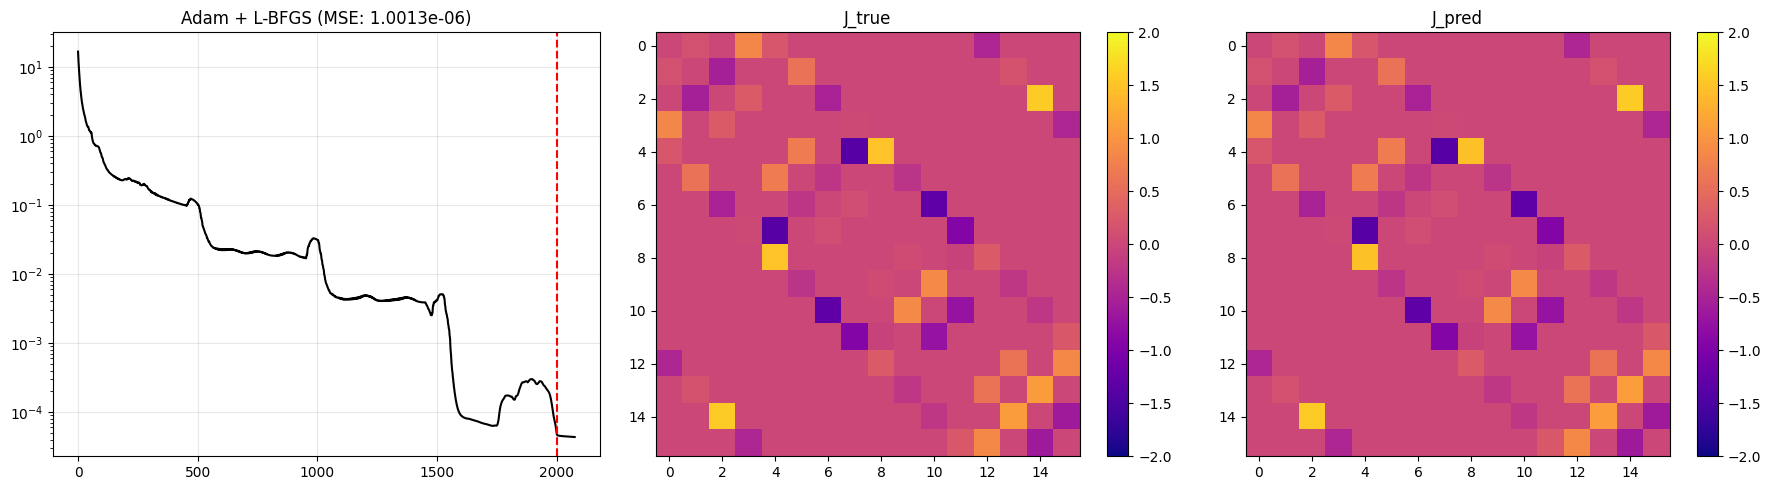

Final MSE: 1.0013e-06
Final MAE: 4.1808e-04
Final Max Error: 5.2722e-03


In [17]:
model_cnn, hist_cnn, mse_cnn, j_pred_cnn = run_cnn_hybrid_training(data_4x4, device)

plot_hybrid_results(
    hist_cnn, mse_cnn, j_pred_cnn, data_4x4['j_true'], 
    adam_epochs=2000, 
    save_name="experiment_cnn_hybrid"
)

calculate_final_metrics(data_4x4['j_true'], j_pred_cnn)

### 2) время трансформера

AdamPhase:   0%|          | 0/2000 [00:00<?, ?it/s]

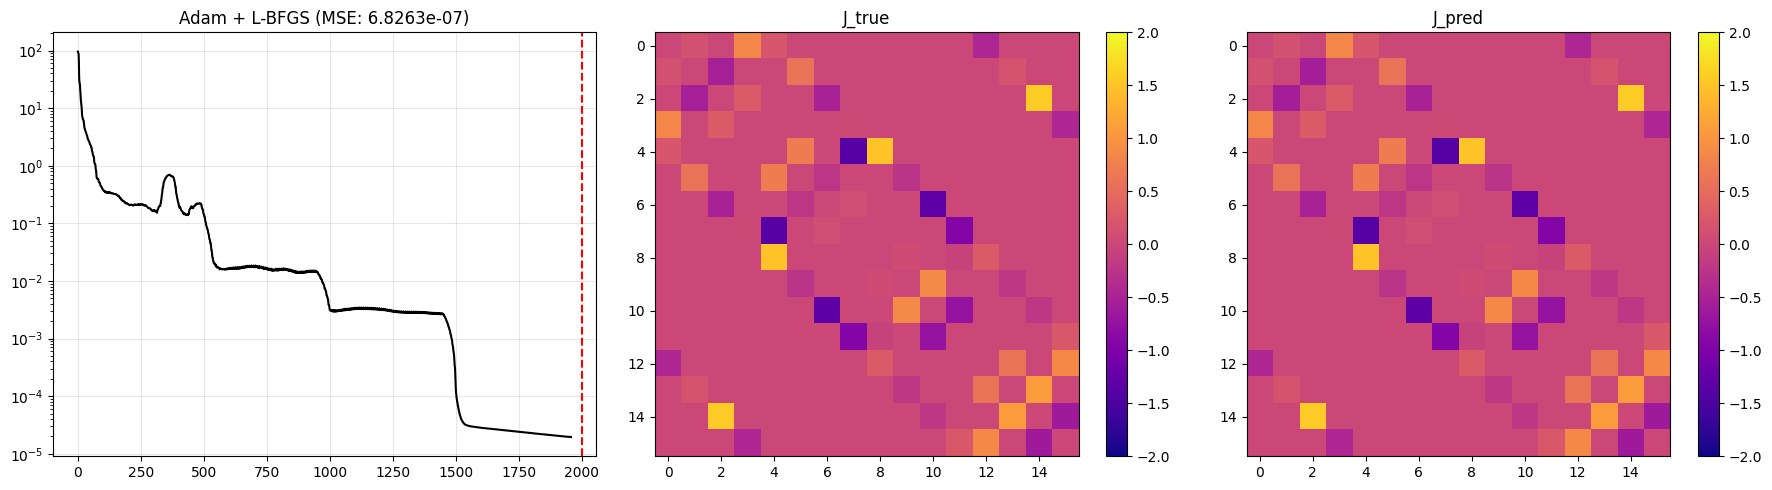

Final MSE: 6.8263e-07
Final MAE: 3.2930e-04
Final Max Error: 4.0665e-03


In [18]:
class AttentionIsingPINN(nn.Module):
    def __init__(self, n, adj, d_model=64, nhead=4, num_layers=2, device='cpu'):
        super().__init__()
        self.n = n
        self.adj = adj
        self.register_buffer('diag_mask', 1.0 - torch.eye(n, device=device))
        
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 2, 
            activation='gelu', 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mlp = nn.Sequential(
            nn.Linear(n * d_model, 256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, n * n)
        )

    def forward(self, x):
        b = x.size(0)
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.reshape(b, -1)

        out = self.mlp(x)
        matrices = out.view(-1, self.n, self.n)
        j_pred = 0.5 * (matrices + matrices.transpose(1, 2))
        j_pred = j_pred * self.adj
        j_pred = j_pred * self.diag_mask
        
        return j_pred

def run_attention_training(data, device):
    clear_memory()
    set_seed(123)

    model = AttentionIsingPINN(
        n=data['n'], 
        adj=data['adj'], 
        d_model=64, 
        nhead=4, 
        num_layers=2, 
        device=device
    ).to(device)

    hist_adam = run_adam_phase(model, data, epochs=2000, batch_size=1024)
    hist_lbfgs = run_lbfgs_phase(model, data, max_iter=100, batch_size=1024)
    full_history = hist_adam + hist_lbfgs
    
    with torch.no_grad():
        j_pred_final = model(data['states'][0].unsqueeze(0))[0]
        mse_err = torch.mean((data['j_true'] - j_pred_final.detach())**2).item()
        
    return model, full_history, mse_err, j_pred_final.detach()

model_attn, hist_attn, mse_attn, j_pred_attn = run_attention_training(data_4x4, device)

plot_hybrid_results(
    hist_attn, mse_attn, j_pred_attn, data_4x4['j_true'], 
    adam_epochs=2000, 
    save_name="experiment_attention_hybrid"
)

calculate_final_metrics(data_4x4['j_true'], j_pred_attn)

### 3) ResNet + self-attention

AdamPhase:   0%|          | 0/5000 [00:00<?, ?it/s]


[Attention+ResNet] MSE (Single state): 3.5184e-07 | MSE (Full grid): 2.7387e-08



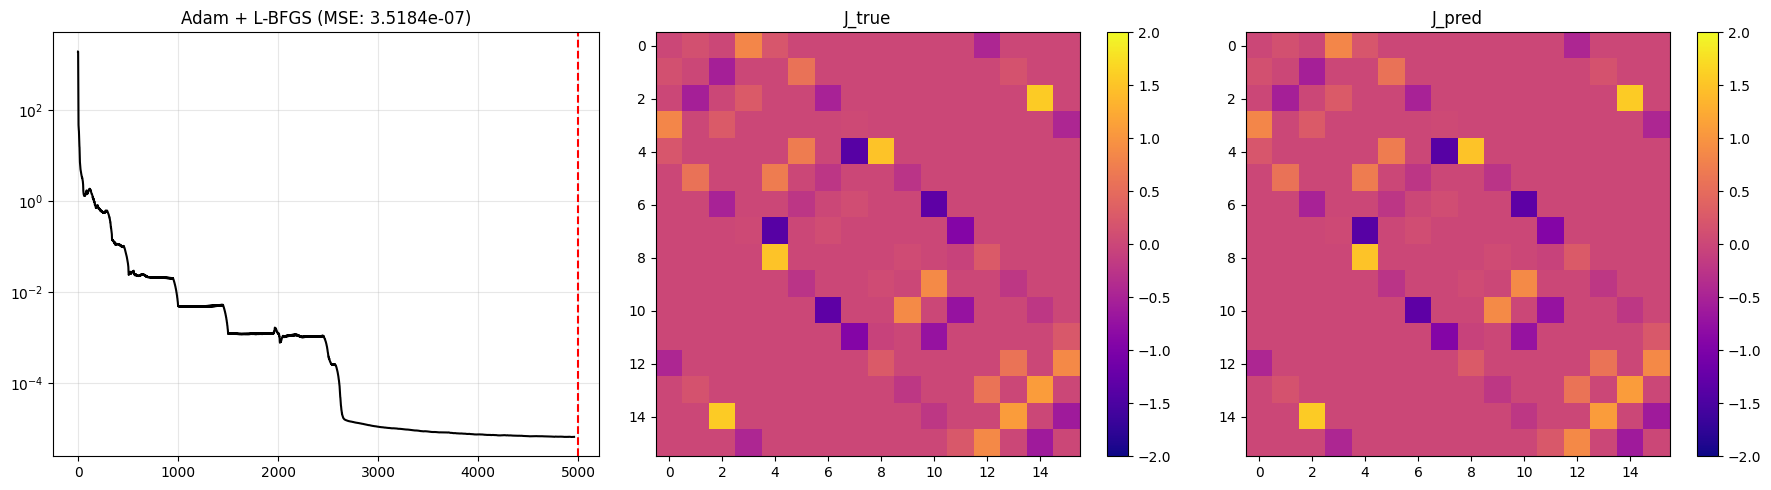

Final MSE: 3.5184e-07
Final MAE: 2.4186e-04
Final Max Error: 3.0372e-03


In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.act = nn.GELU()
        
    def forward(self, x):
        return self.act(x + self.net(x))

class AttentionResNetPINN(nn.Module):
    def __init__(self, n, adj, d_model=64, nhead=4, num_tf_layers=2, num_res_blocks=3, device='cpu'):
        super().__init__()
        self.n = n
        self.adj = adj
        self.register_buffer('diag_mask', 1.0 - torch.eye(n, device=device))
        
        self.embedding = nn.Linear(1, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, 
            dim_feedforward=d_model * 2, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_tf_layers)
        
        flat_dim = n * d_model
        self.pre_res = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.GELU()
        )
        
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(512) for _ in range(num_res_blocks)]
        )
        
        self.head = nn.Linear(512, n * n)

    def forward(self, x):
        b = x.size(0)
        x = x.unsqueeze(-1)
        
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.reshape(b, -1)
        
        x = self.pre_res(x)
        x = self.res_blocks(x)
        out = self.head(x)
        
        matrices = out.view(-1, self.n, self.n)
        j_pred = 0.5 * (matrices + matrices.transpose(1, 2))
        j_pred = j_pred * self.adj
        j_pred = j_pred * self.diag_mask
        
        return j_pred

def run_adam_phase_step(model, data, epochs, batch_size):
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)
    history = []
    pbar = tqdm(range(1, epochs + 1), desc="AdamPhase")
    for epoch in pbar:
        optimizer.zero_grad()
        indices = torch.multinomial(data['p_true'], batch_size, replacement=True)
        batch_states = data['states'][indices]
        j_pred_batch = model(batch_states)
        loss = compute_pinn_loss(data['states'], j_pred_batch, data['corr2_true'], data['h_mean_true'], data['beta'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        history.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4e}'})
    return history

def run_attn_resnet_training(data, device):
    clear_memory()
    set_seed(123)
    model = AttentionResNetPINN(
        n=data['n'], adj=data['adj'], d_model=64, nhead=4, 
        num_tf_layers=2, num_res_blocks=4, device=device
    ).to(device)
    
    hist_adam = run_adam_phase_step(model, data, epochs=5000, batch_size=1024)
    hist_lbfgs = run_lbfgs_phase(model, data, max_iter=300, batch_size=1024)
    full_history = hist_adam + hist_lbfgs
    
    with torch.no_grad():
        j_pred_final = model(data['states'][0].unsqueeze(0))[0]
        mse_err_single = torch.mean((data['j_true'] - j_pred_final.detach())**2).item()
        
        j_pred_full = compute_full_grid_j_pred(model, data['states'], batch_size=1024)
        mse_err_full = torch.mean((data['j_true'] - j_pred_full)**2).item()
        
        print(f"\n[Attention+ResNet] MSE (Single state): {mse_err_single:.4e} | MSE (Full grid): {mse_err_full:.4e}\n")
        
    return model, full_history, mse_err_single, j_pred_final.detach()

model_ar, hist_ar, mse_ar, j_pred_ar = run_attn_resnet_training(data_4x4, device)

plot_hybrid_results(
    hist_ar, mse_ar, j_pred_ar, data_4x4['j_true'], 
    adam_epochs=5000, 
    save_name="experiment_resnet_hybrid"
)

calculate_final_metrics(data_4x4['j_true'], j_pred_ar)